# Prediccion Inteligente de Inventarios

## Prediccion de Inventarios: contexto del caso

**Tipo de modelo:** Regresion supervisada (GradientBoostingRegressor vs LinearRegression)
**Variable objetivo:** demanda_siguiente_semana - unidades que se venderian la semana proxima por SKU

**Lo que aprenderas en este notebook:**
1. Como cargar y explorar un dataset de inventario real con pandas
2. Por que la division temporal (no aleatoria) es obligatoria en series temporales
3. Como comparar dos modelos de regresion con scikit-learn
4. Como interpretar predicciones en terminos de negocio
5. Cuando este modelo NO debe usarse

---


## Contexto del caso de negocio

| | |
|---|---|
| **Empresa** | empresa — área de operaciones y logística |
| **Problema de negocio** | Determinar cuántas unidades de cada SKU pedir la semana siguiente para evitar roturas de stock y exceso de inventario |
| **Datos disponibles** | 300 registros históricos semanales por producto: categoría, stock actual, ventas recientes, temporada, promoción activa y demanda real de la semana siguiente |
| **Técnica aplicada** | Regresión supervisada con GradientBoostingRegressor y regresión lineal como baseline; split temporal (semanas 1-48 entreno, resto test) para respetar el orden cronológico |
| **Salida del modelo** | Predicción numérica de unidades demandadas la semana siguiente para cada SKU |
| **Valor operativo** | Permite automatizar las órdenes de reposición reduciendo tanto el sobrestock como las roturas; el error del modelo (MAE) se traduce directamente en coste de inventario evitable |

In [1]:
import os, sys
from pathlib import Path

# Configuracion de entorno: ajusta CWD y descarga datos segun el entorno de ejecucion
_BASE_URL = "https://raw.githubusercontent.com/amador2001/ia-datos/main/"
_CSVS = ["inventarios_empresa.csv"]

if "google.colab" in sys.modules:
    import urllib.request
    Path("datos").mkdir(exist_ok=True)
    for _csv in _CSVS:
        _dest = Path("datos") / _csv
        if not _dest.exists():
            urllib.request.urlretrieve(_BASE_URL + _csv, str(_dest))
            print(f"Descargado: {_csv}")
elif "__vsc_ipynb_file__" in dir():
    os.chdir(Path(__vsc_ipynb_file__).parent)
elif not Path("datos").exists():
    for _p in [Path("Jupyter_notebooks"), Path("../Jupyter_notebooks")]:
        if (_p / "datos").exists():
            os.chdir(_p)
            break

print(f"Entorno listo. CWD: {os.getcwd()}")

Entorno listo. CWD: /home/amador/compartido/alh-python/projects/formación_AI_springter/Jupyter_notebooks


In [2]:
# Librerias de manipulacion de datos
import numpy as np           # operaciones numericas vectorizadas
import pandas as pd          # carga y manipulacion de tablas de datos

# Visualizacion
import matplotlib.pyplot as plt   # graficas base
import seaborn as sns             # graficas estadisticas sobre matplotlib

# Modelos de machine learning
from sklearn.linear_model import LinearRegression          # modelo lineal como baseline
from sklearn.ensemble import GradientBoostingRegressor     # modelo de ensamble basado en arboles
from sklearn.metrics import mean_absolute_error, mean_squared_error  # metricas de error
from sklearn.preprocessing import LabelEncoder, StandardScaler       # preprocesamiento
from sklearn.pipeline import Pipeline                                 # encadenar pasos

# Configuracion visual
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


In [3]:
# ── Carga del dataset desde archivo CSV ────────────────────────────────────────────
# pd.read_csv lee el archivo y lo convierte en un DataFrame (tabla de datos)
df = pd.read_csv("datos/inventarios_empresa.csv")

# Mostrar las primeras filas para verificar la carga
print("Primeras filas del dataset:")
display(df.head(10))

# Resumen estadistico: media, desviacion, min, max de cada columna numerica
print("\nEstadisticas descriptivas:")
display(df.describe().round(2))

# Informacion general: tipos de datos y valores nulos
print("\nInformacion del dataset:")
df.info()

print(f"\nDimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Productos unicos: {df['producto_id'].nunique()}")
print(f"Semanas: {df['semana'].min()} a {df['semana'].max()}")


Primeras filas del dataset:


,semana,producto_id,categoria,stock_actual,pedidos_pendientes,temporada,dias_desde_ultimo_pedido,demanda_media_historica,promo_activa,demanda_siguiente_semana
0,1,SKU-001,Hardware,360,22,alta,11,255.0,0,243.9
1,2,SKU-001,Hardware,266,35,alta,8,258.0,0,261.2
2,3,SKU-001,Hardware,341,20,alta,1,260.9,0,256.2
3,4,SKU-001,Hardware,171,43,alta,25,263.7,0,269.1
4,5,SKU-001,Hardware,369,15,baja,15,152.2,0,142.1
5,6,SKU-001,Hardware,324,43,baja,23,153.5,0,156.6
6,7,SKU-001,Hardware,284,20,baja,9,154.8,0,166.1
7,8,SKU-001,Hardware,281,24,baja,28,155.9,1,201.6
8,9,SKU-001,Hardware,279,19,baja,28,156.8,0,155.4
9,10,SKU-001,Hardware,348,43,baja,29,157.5,0,157.2



Estadisticas descriptivas:


,semana,stock_actual,pedidos_pendientes,dias_desde_ultimo_pedido,demanda_media_historica,promo_activa,demanda_siguiente_semana
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,30.50,278.94,24.92,15.15,120.98,0.15,127.24
std,17.35,69.87,14.09,8.62,52.75,0.36,56.61
min,1.00,150.00,0.00,1.00,43.20,0.00,35.00
25%,15.75,216.00,14.00,7.00,81.30,0.00,84.75
50%,30.50,278.00,25.00,16.00,118.25,0.00,118.60
75%,45.25,339.50,37.00,23.00,154.20,0.00,156.95
max,60.00,398.00,49.00,29.00,263.70,1.00,294.30



Informacion del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   semana                    300 non-null    int64  
 1   producto_id               300 non-null    object 
 2   categoria                 300 non-null    object 
 3   stock_actual              300 non-null    int64  
 4   pedidos_pendientes        300 non-null    int64  
 5   temporada                 300 non-null    object 
 6   dias_desde_ultimo_pedido  300 non-null    int64  
 7   demanda_media_historica   300 non-null    float64
 8   promo_activa              300 non-null    int64  
 9   demanda_siguiente_semana  300 non-null    float64
dtypes: float64(2), int64(5), object(3)
memory usage: 23.6+ KB

Dimensiones: 300 filas x 10 columnas
Productos unicos: 5
Semanas: 1 a 60


### Variables del dataset

| Variable | Tipo | Descripcion |
|---|---|---|
| semana | int | Numero de semana del historico (1-60) |
| producto_id | str | Identificador del SKU |
| categoria | str | Categoria del producto (Hardware/Software/Servicios) |
| stock_actual | int | Unidades en almacen al inicio de la semana |
| pedidos_pendientes | int | Pedidos ya realizados pero no entregados |
| temporada | str | Alta / media / baja segun calendario comercial |
| dias_desde_ultimo_pedido | int | Dias transcurridos desde el ultimo pedido al proveedor |
| demanda_media_historica | float | Media movil de demanda de las ultimas 8 semanas |
| promo_activa | int | 1 si hay promocion activa esa semana, 0 si no |
| demanda_siguiente_semana | float | **Variable objetivo**: unidades vendidas la semana siguiente |

> La variable objetivo es una estimacion futura. El modelo aprende el patron historico
> para predecir cuantas unidades se necesitaran la proxima semana.


/tmp/ipykernel_871900/519361822.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="categoria", y="demanda_siguiente_semana",


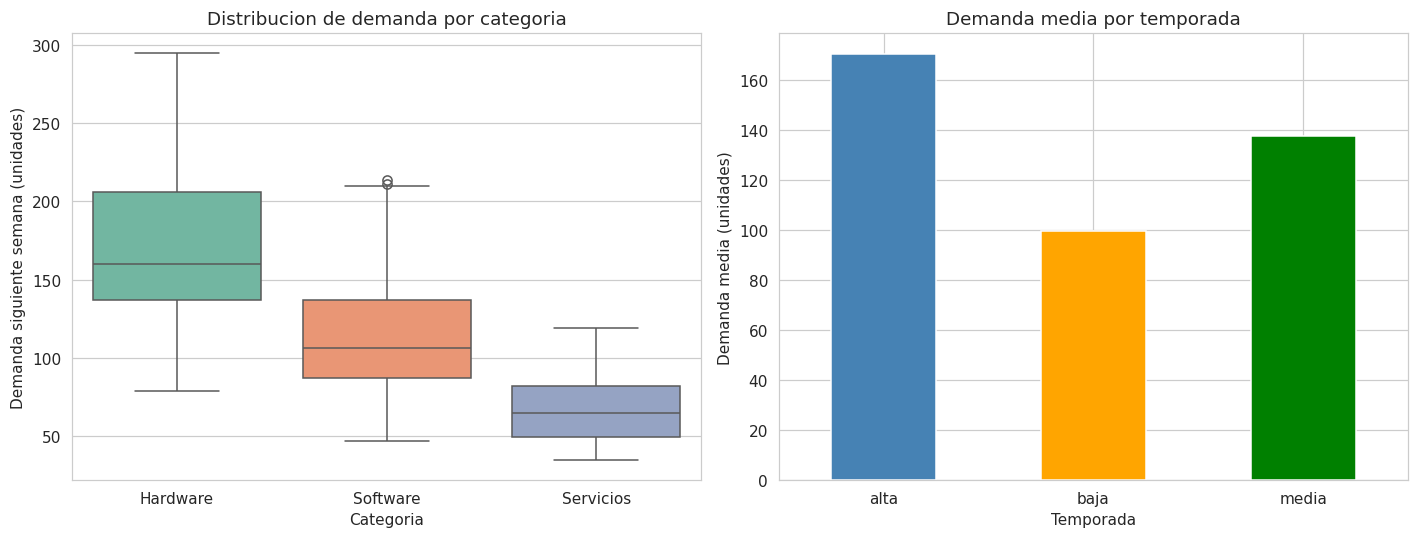


Correlacion de cada variable con demanda_siguiente_semana:


,demanda_siguiente_semana
demanda_siguiente_semana,1.000
demanda_media_historica,0.956
promo_activa,0.152
semana,0.098
stock_actual,0.080
pedidos_pendientes,-0.002
dias_desde_ultimo_pedido,-0.029


In [4]:
# ── Analisis Exploratorio de Datos (EDA) ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grafica izquierda: distribucion de demanda por categoria
# Un boxplot muestra mediana, cuartiles y outliers para comparar grupos
sns.boxplot(data=df, x="categoria", y="demanda_siguiente_semana",
            palette="Set2", ax=axes[0])
axes[0].set_title("Distribucion de demanda por categoria")
axes[0].set_xlabel("Categoria")
axes[0].set_ylabel("Demanda siguiente semana (unidades)")

# Grafica derecha: demanda media segun temporada
# La estacionalidad es un factor clave en prediccion de inventarios
demanda_temporada = df.groupby("temporada")["demanda_siguiente_semana"].mean()
demanda_temporada.plot(kind="bar", color=["steelblue","orange","green"],
                       ax=axes[1], rot=0)
axes[1].set_title("Demanda media por temporada")
axes[1].set_xlabel("Temporada")
axes[1].set_ylabel("Demanda media (unidades)")

plt.tight_layout()
plt.show()

# Mostrar correlacion de variables con el target
print("\nCorrelacion de cada variable con demanda_siguiente_semana:")
display(df.select_dtypes(include="number")
          .corr()[["demanda_siguiente_semana"]]
          .sort_values("demanda_siguiente_semana", ascending=False)
          .round(3))


### Por que dividimos por tiempo y no de forma aleatoria

En series temporales, dividir aleatoriamente seria trampa:
el modelo entrenaria con datos futuros para predecir el pasado.

La regla es simple: **entrena con lo antiguo, evalua con lo reciente**.

```
Semanas 1-48  →  Entrenamiento (80%)
Semanas 49-60 →  Test (20%)
```

Si dividieramos aleatoriamente, el modelo "veria el futuro" durante el entrenamiento
y sus metricas en test serian artificialmente buenas.


In [5]:
# ── Preprocesamiento ────────────────────────────────────────────────────────────────

# Codificar variables categoricas: el modelo necesita numeros, no texto
# LabelEncoder convierte cada categoria unica en un entero
le_prod = LabelEncoder()
le_cat  = LabelEncoder()
le_temp = LabelEncoder()

df["producto_enc"] = le_prod.fit_transform(df["producto_id"])   # SKU-001=0, SKU-002=1, ...
df["categoria_enc"] = le_cat.fit_transform(df["categoria"])     # Hardware=0, Servicios=1, ...
df["temporada_enc"] = le_temp.fit_transform(df["temporada"])    # alta=0, baja=1, media=2

# Definir las variables de entrada (features) y la variable objetivo (target)
FEATURES = ["producto_enc", "categoria_enc", "stock_actual", "pedidos_pendientes",
            "temporada_enc", "dias_desde_ultimo_pedido", "demanda_media_historica",
            "promo_activa"]
TARGET = "demanda_siguiente_semana"

# ── Split temporal (semana 48 como corte) ────────────────────────────────────────────
# El corte en semana 48 deja las ultimas 12 semanas para test (~20% del historico)
SEMANA_CORTE = 48

train = df[df["semana"] <= SEMANA_CORTE]   # datos historicos para entrenar
test  = df[df["semana"]  > SEMANA_CORTE]   # datos recientes para evaluar

X_train = train[FEATURES]   # features de entrenamiento
y_train = train[TARGET]     # target de entrenamiento
X_test  = test[FEATURES]    # features de evaluacion
y_test  = test[TARGET]      # target real (para comparar con predicciones)

print(f"Filas de entrenamiento: {len(X_train)}")
print(f"Filas de test:          {len(X_test)}")
print(f"\nPrimeras filas del set de entrenamiento:")
display(pd.DataFrame(X_train).head())


Filas de entrenamiento: 240
Filas de test:          60

Primeras filas del set de entrenamiento:


,producto_enc,categoria_enc,stock_actual,pedidos_pendientes,temporada_enc,dias_desde_ultimo_pedido,demanda_media_historica,promo_activa
0,0,0,360,22,0,11,255.0,0
1,0,0,266,35,0,8,258.0,0
2,0,0,341,20,0,1,260.9,0
3,0,0,171,43,0,25,263.7,0
4,0,0,369,15,1,15,152.2,0


In [6]:
# ── Modelo 1: Regresion Lineal con normalizacion ──────────────────────────────────────────────
# LinearRegression asume que las features tienen escalas similares.
# StandardScaler normaliza cada columna a media=0, desviacion=1.
# Pipeline encadena el escalado y el modelo en un solo objeto.
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),     # paso 1: normalizar las features
    ("model",  LinearRegression())    # paso 2: entrenar el modelo lineal
])
pipe_lr.fit(X_train, y_train)         # aprender la relacion features -> target en train

# ── Modelo 2: Gradient Boosting (no necesita normalizacion) ───────────────────────────────────────────
# Los arboles de decision no son sensibles a la escala de las features,
# por eso GradientBoostingRegressor no necesita StandardScaler.
gbr = GradientBoostingRegressor(
    n_estimators=100,   # numero de arboles en el ensamble
    max_depth=4,        # profundidad maxima de cada arbol
    learning_rate=0.1,  # tasa de aprendizaje: cuanto corrige cada arbol el error anterior
    random_state=42     # semilla para reproducibilidad
)
gbr.fit(X_train, y_train)   # entrenar el modelo de gradient boosting

# ── Predicciones sobre el conjunto de test ────────────────────────────────────────────────────
y_pred_lr  = pipe_lr.predict(X_test)   # predicciones del modelo lineal
y_pred_gbr = gbr.predict(X_test)       # predicciones del gradient boosting

# ── Metricas de evaluacion ─────────────────────────────────────────────────────────────────
# MAE: error medio absoluto en unidades (cuanto se equivoca en promedio)
# RMSE: raiz del error cuadratico medio (penaliza errores grandes mas que MAE)
print("Comparativa de modelos en test:")
print(f"  LinearRegression  — MAE: {mean_absolute_error(y_test, y_pred_lr):.1f} unidades | RMSE: {mean_squared_error(y_test, y_pred_lr, squared=False):.1f}")
print(f"  GradientBoosting  — MAE: {mean_absolute_error(y_test, y_pred_gbr):.1f} unidades | RMSE: {mean_squared_error(y_test, y_pred_gbr, squared=False):.1f}")

# Mostrar tabla comparativa de predicciones vs real para los primeros 10 casos
comparativa = pd.DataFrame({
    "demanda_real": y_test.values[:10].round(1),
    "pred_lineal":  y_pred_lr[:10].round(1),
    "pred_gbr":     y_pred_gbr[:10].round(1)
})
print("\nPrimeras 10 predicciones vs demanda real:")
display(comparativa)


Comparativa de modelos en test:
  LinearRegression  — MAE: 9.3 unidades | RMSE: 12.5
  GradientBoosting  — MAE: 9.6 unidades | RMSE: 11.8

Primeras 10 predicciones vs demanda real:


,demanda_real,pred_lineal,pred_gbr
0,252.3,247.6,241.1
1,243.7,248.0,247.8
2,254.7,252.2,246.5
3,250.4,257.4,241.9
4,255.0,259.5,244.5
5,254.2,263.5,246.4
6,267.2,264.9,248.7
7,294.3,265.6,261.2
8,164.3,153.7,149.8
9,158.9,155.0,154.1


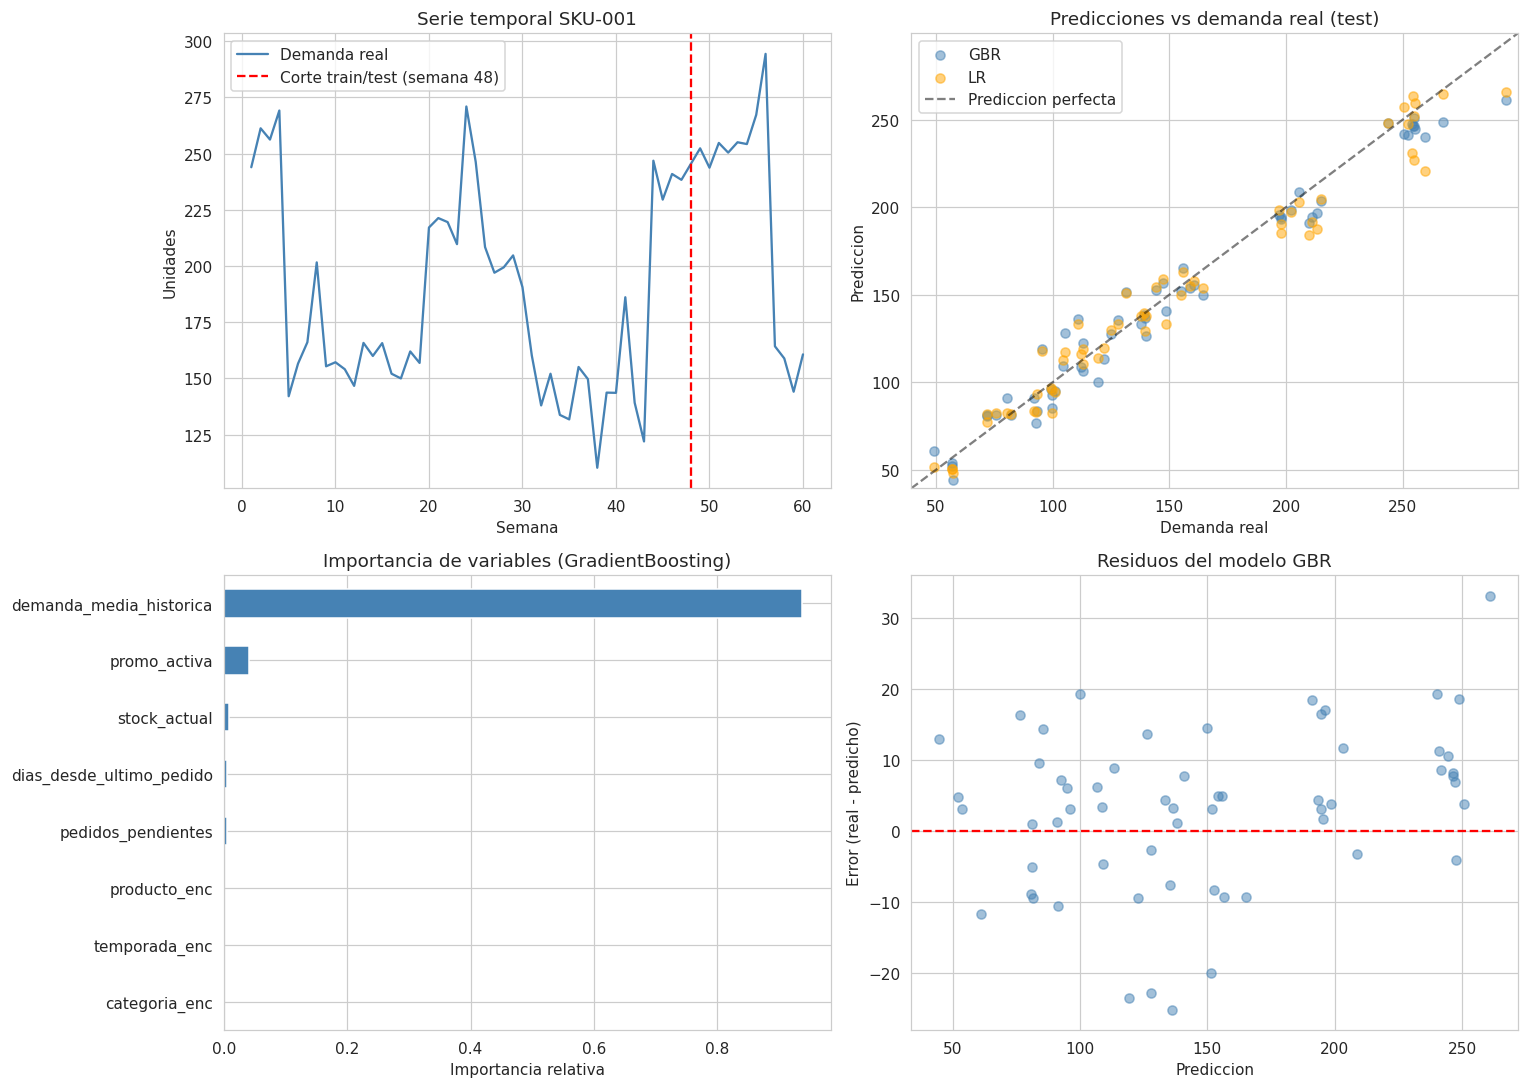

In [7]:
# ── Grafica 1: Serie temporal de un SKU con corte train/test ──────────────────────────────────────────────
sku = "SKU-001"
df_sku = df[df["producto_id"] == sku].sort_values("semana")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Serie temporal con linea de corte visible
ax = axes[0, 0]
ax.plot(df_sku["semana"].to_numpy(), df_sku[TARGET].to_numpy(), label="Demanda real", color="steelblue")
ax.axvline(SEMANA_CORTE, color="red", linestyle="--", label=f"Corte train/test (semana {SEMANA_CORTE})")
ax.set_title(f"Serie temporal {sku}")
ax.set_xlabel("Semana")
ax.set_ylabel("Unidades")
ax.legend()

# Predicciones vs real (scatter): puntos cercanos a la diagonal = buenas predicciones
ax = axes[0, 1]
ax.scatter(y_test, y_pred_gbr, alpha=0.5, color="steelblue", label="GBR")
ax.scatter(y_test, y_pred_lr,  alpha=0.5, color="orange",    label="LR")
lim = [min(y_test.min(), y_pred_gbr.min())-5, max(y_test.max(), y_pred_gbr.max())+5]
ax.plot(lim, lim, "k--", alpha=0.5, label="Prediccion perfecta")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_title("Predicciones vs demanda real (test)")
ax.set_xlabel("Demanda real"); ax.set_ylabel("Prediccion")
ax.legend()

# Feature importance: que variables importan mas al modelo
ax = axes[1, 0]
fi = pd.Series(gbr.feature_importances_, index=FEATURES).sort_values(ascending=True)
fi.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Importancia de variables (GradientBoosting)")
ax.set_xlabel("Importancia relativa")

# Residuos: diferencia entre real y predicho (sin patron = buen modelo)
ax = axes[1, 1]
residuos = y_test.values - y_pred_gbr
ax.scatter(y_pred_gbr, residuos, alpha=0.5, color="steelblue")
ax.axhline(0, color="red", linestyle="--")
ax.set_title("Residuos del modelo GBR")
ax.set_xlabel("Prediccion")
ax.set_ylabel("Error (real - predicho)")

plt.tight_layout()
plt.show()


In [8]:
# ── Ejemplo de prediccion para un caso nuevo ─────────────────────────────────────────────────────
# Supongamos que necesitamos predecir la demanda de SKU-001 la proxima semana
nuevo_caso = pd.DataFrame([{
    "producto_enc":             le_prod.transform(["SKU-001"])[0],
    "categoria_enc":            le_cat.transform(["Hardware"])[0],
    "stock_actual":             220,       # unidades actuales en almacen
    "pedidos_pendientes":       15,        # pedidos ya realizados al proveedor
    "temporada_enc":            le_temp.transform(["alta"])[0],
    "dias_desde_ultimo_pedido": 7,         # hace 7 dias se hizo el ultimo pedido
    "demanda_media_historica":  185.0,     # media de las ultimas 8 semanas
    "promo_activa":             1          # hay promocion activa esta semana
}])

# predict() devuelve la demanda estimada para la semana siguiente
prediccion = gbr.predict(nuevo_caso)[0]

print(f"Prediccion de demanda para SKU-001 la proxima semana: {prediccion:.0f} unidades")
print(f"\nInterpretacion de negocio:")
print(f"  Stock actual:       220 unidades")
print(f"  Demanda estimada:   {prediccion:.0f} unidades")
print(f"  Pedidos pendientes: 15 unidades")
print(f"  Deficit estimado:   {max(0, prediccion - 220 - 15):.0f} unidades")
if prediccion > 220 + 15:
    print(f"  ACCION: lanzar pedido al proveedor para cubrir el deficit")
else:
    print(f"  Sin necesidad de pedido urgente esta semana")


Prediccion de demanda para SKU-001 la proxima semana: 212 unidades

Interpretacion de negocio:
  Stock actual:       220 unidades
  Demanda estimada:   212 unidades
  Pedidos pendientes: 15 unidades
  Deficit estimado:   0 unidades
  Sin necesidad de pedido urgente esta semana


### Cuando NO usar este modelo

| Situacion | Por que no funciona |
|---|---|
| Nuevo producto sin historico | El modelo necesita al menos 8-12 semanas de datos |
| Cambio estructural de negocio | Si cambia el patron de demanda (nuevo canal, crisis), el modelo queda desactualizado |
| Demanda muy estacional y corta | Con pocos ciclos completos, el modelo no aprende la estacionalidad |
| Eventos extraordinarios | Pandemias, lanzamientos virales, crisis de suministro no estan en el historico |

> El modelo es tan bueno como los datos que lo alimentan.
> Si el historico tiene errores o gaps, las predicciones los heredan.
